#  Propagação de Epidemias  (Lab9)

## Support Functions 

In [1]:
! pip install networkx pandas numpy matplotlib  -q

In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from typing import List
import math

seed = 96
np.random.seed(seed)

In [3]:
get_degress = lambda G: [d for _, d in G.degree()]

def degree_moment(G, n):
    degrees = np.array(get_degress(G), dtype=float)

    if len(degrees) == 0:
        return 0.0

    return np.mean(degrees ** n)

In [4]:
def plot_degree_distribution_loglog(graphs, ncols=2):
    nrows = math.ceil(len(graphs) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(6 * ncols, 5 * nrows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, (title, G) in zip(axes, graphs.items()):
        degrees = np.array(get_degress(G))
        degrees = degrees[degrees > 0]

        unique_degrees, counts = np.unique(degrees, return_counts=True)
        probabilities = counts / counts.sum()

        ax.scatter(
            unique_degrees,
            probabilities,
            s=20
        )

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_title(title)
        ax.set_xlabel("Degree k")
        ax.set_ylabel("P(k)")
        ax.grid(True, which="both", alpha=0.3)

    for ax in axes[len(graphs):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
def nonlinear_ba(n, m, alpha, seed=None):
     
    rng = np.random.default_rng(seed)
    G = nx.star_graph(m)
 
    for new_node in range(m + 1, n):
        nodes = np.fromiter(G.nodes(), dtype=int)
        degrees = np.fromiter((d for _, d in G.degree()), dtype=float)
 
        # pesos não lineares: k^alpha
        weights = np.power(degrees, alpha)
        total = weights.sum()
        probs = np.full(len(nodes), 1.0 / len(nodes)) if total == 0 else weights / total
 
        # m alvos distintos, escolhidos proporcionalmente a k^alpha
        targets = rng.choice(nodes, size=m, replace=False, p=probs)
 
        G.add_node(new_node)
        G.add_edges_from((new_node, int(t)) for t in targets)
 
    return G

## Epidemias

As redes  Watts Strogatz (WS) e (ER)

#### Casos interessantes

Em algumas execuções, determinadas redes apresentaram média de infectados igual a zero. Esse comportamento ocorreu com maior frequência nas redes ER e WS, nas quais os nós tendem a apresentar menor conectividade média local quando comparados, por exemplo, a redes com hubs mais pronunciados, como as redes BA.

Esse efeito está relacionado ao sorteio aleatório do paciente zero. Quando o nó inicialmente infectado possui poucas conexões, a probabilidade de ele transmitir a infecção antes de se recuperar é menor. Como neste experimento foi utilizado $\mu = 1$, o nó infectado se recupera a cada passo de tempo com probabilidade máxima. Assim, caso o paciente zero não infecte nenhum vizinho imediatamente, a cadeia de transmissão é interrompida logo no início, resultando em uma simulação na qual apenas o paciente zero foi infectado e a média temporal de infectados tende a zero.


### Gerando redes

In [6]:
N = 1000
k = 8
p_1 = 0.001
p_2 = 0.01

# ER: para obter <k> ~= 8
p_er = k / (N - 1)

# BA: grau médio esperado ~= 2m
m_ba = k // 2


In [7]:
graphs = {}
graphs["ER"] = nx.erdos_renyi_graph(
    n=N,
    p=p_er,
    seed=seed
)

graphs["BA"] = nx.barabasi_albert_graph(
    n=N,
    m=m_ba,
    seed=seed
)

graphs["BA_non_linear_0.5"] = nonlinear_ba(
    n=N,
    m=m_ba,
    seed=seed,
    alpha=0.5
)

graphs["BA_non_linear_1.5"] = nonlinear_ba(
    n=N,
    m=m_ba,
    seed=seed,
    alpha=1.5
)

graphs[f"WS_p_0.001"] = nx.watts_strogatz_graph(
    n=N,
    k=k,
    p=p_1,
    seed=seed
)

graphs[f"WS_p_0.01"] = nx.watts_strogatz_graph(
    n=N,
    k=k,
    p=p_2,
    seed=seed
)

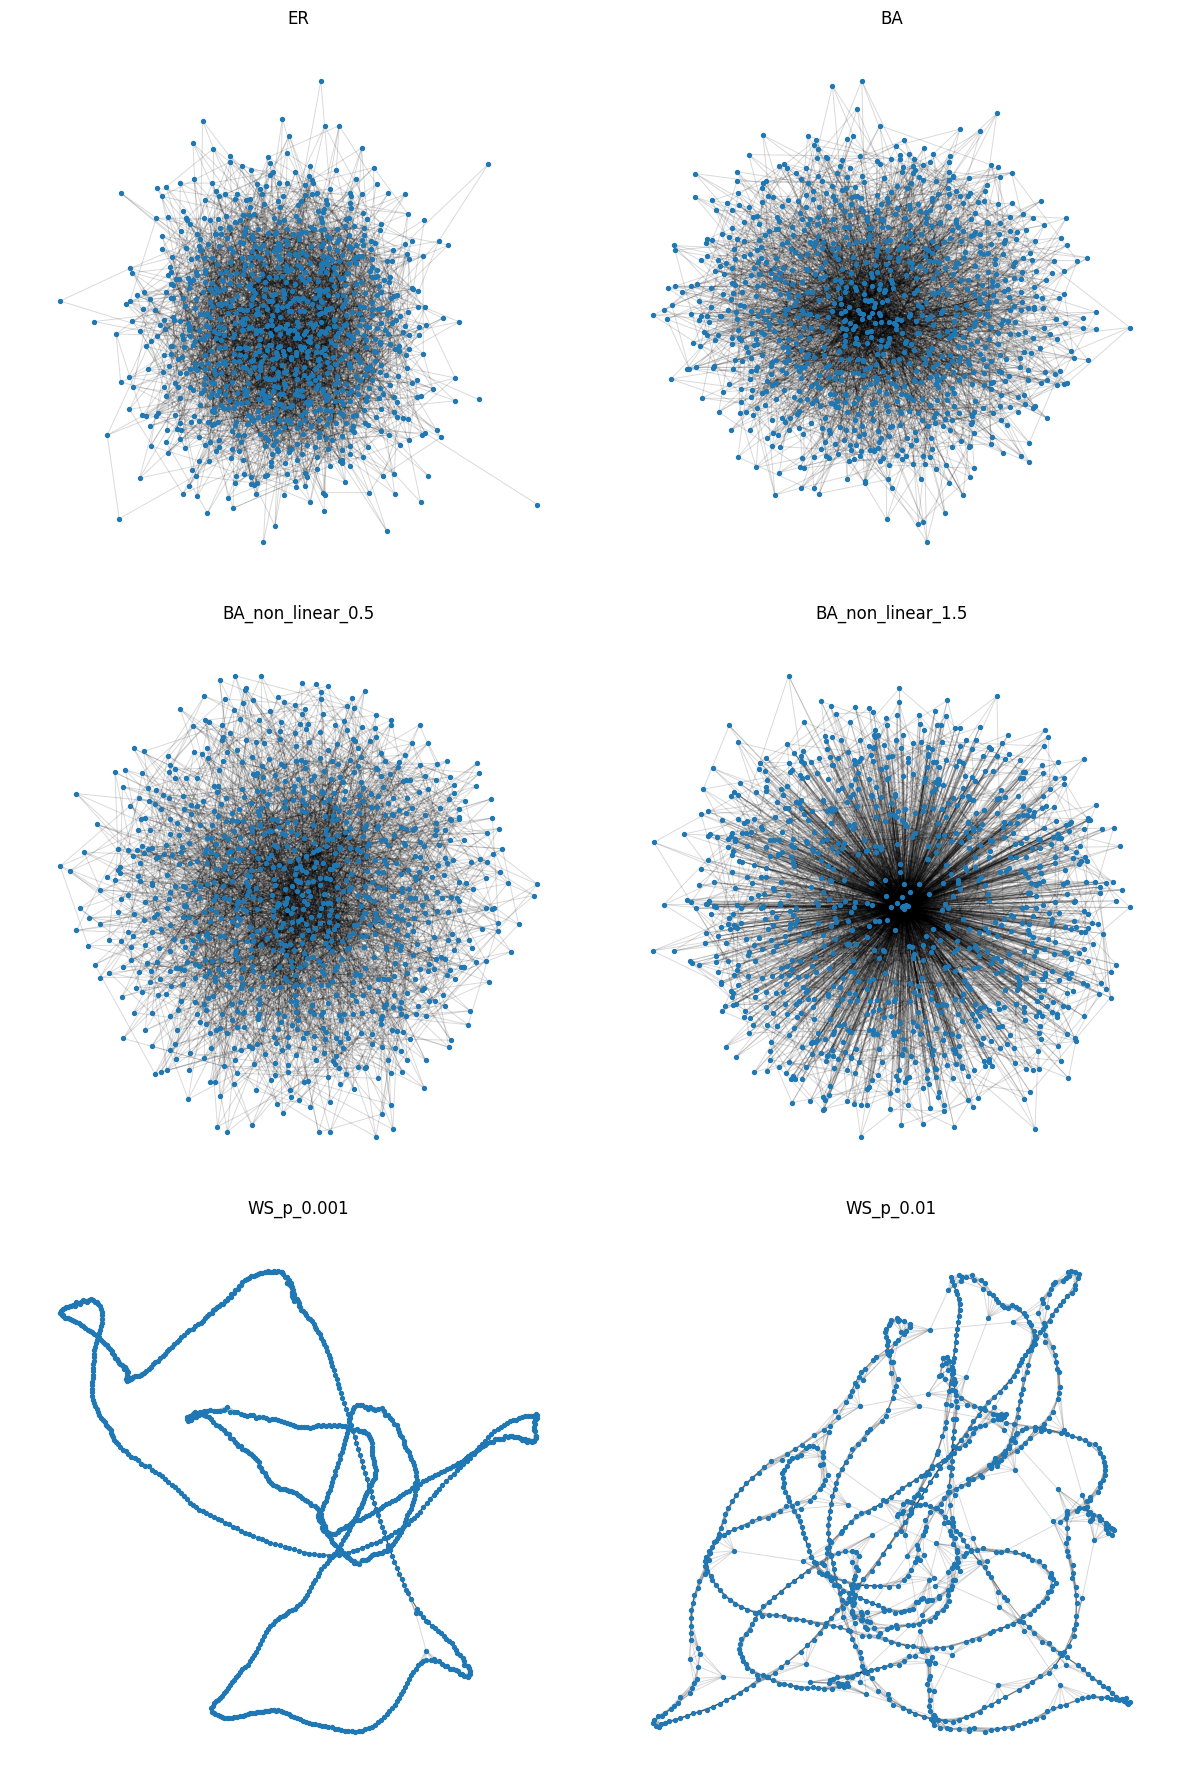

In [8]:
import math

ncols = 2
nrows = math.ceil(len(graphs) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6 * ncols, 6 * nrows)
)

axes = axes.flatten()

for ax, (title, G) in zip(axes, graphs.items()):
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=8
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        alpha=0.15,
        width=0.7
    )

    ax.set_title(title)
    ax.axis("off")

# Remove axes vazios, caso tenha número ímpar de grafos
for ax in axes[len(graphs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

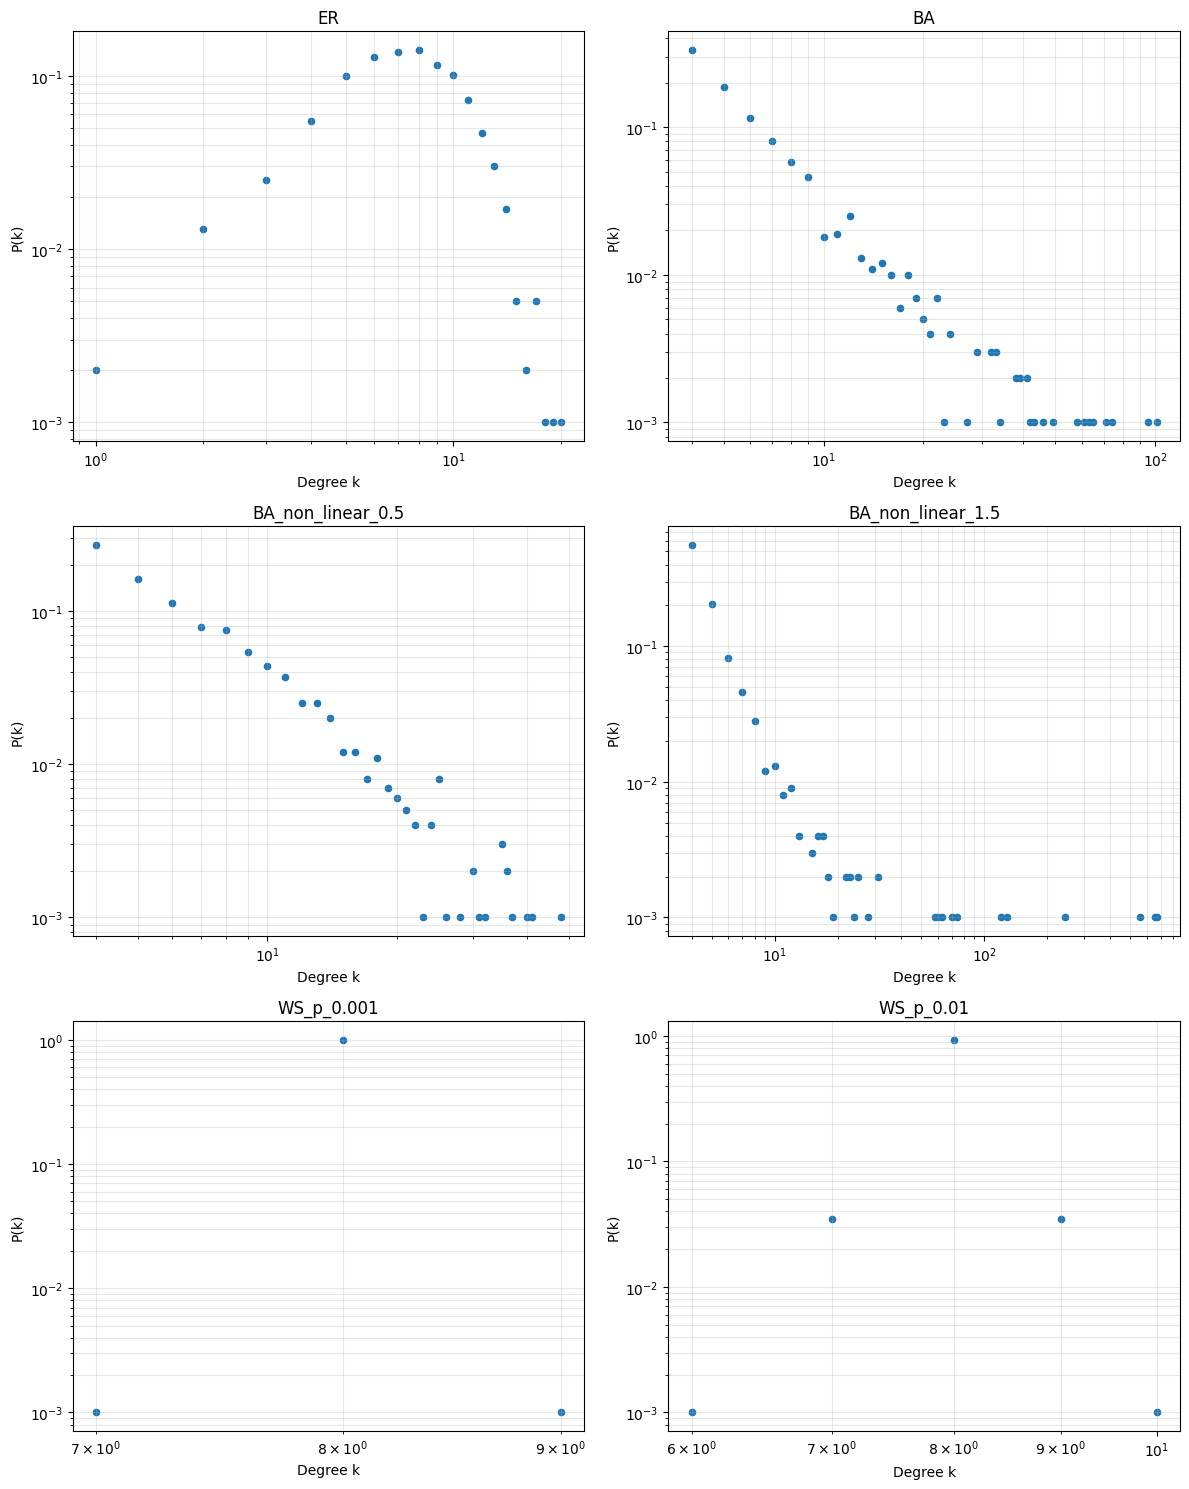

In [9]:
plot_degree_distribution_loglog(graphs)

### Modelos de Epidemia 

In [10]:
def si_time(G: nx.Graph, beta: float, t_max: int) -> tuple[List[float], List[float], List[int]]:

    patient_zero = 0
    population_size = G.number_of_nodes()

    population = np.zeros(population_size)
    population[patient_zero] = 1 # infect first patient

    I = [0]
    S = [1]
    T = [0]

    for t in range(1, t_max+1):
        infecteds = np.where(population==1)[0]
        for i in infecteds: 
            neighbors = G.neighbors(i)
            for j in neighbors:
                if np.random.rand() < beta:
                    population[j] = 1
        
        total_infecteds = np.sum(population)
        total_susceptible = np.count_nonzero(population == 0)
        I.append(total_infecteds/population_size)
        S.append(total_susceptible/population_size)
        T.append(t)


    return I, S, T

In [11]:
def sis_time(G: nx.Graph, beta: float, mu: float, t_max: int ) -> tuple[List[float], List[float], List[int]]:
    patient_zero = 0
    population_size = G.number_of_nodes()

    population = np.zeros(population_size)
    population[patient_zero] = 1 # infect first patient

    I = [0]
    S = [1]
    T = [0]

    for t in range(1, t_max+1):
        infecteds = np.where(population==1)[0]
        for i in infecteds: 
            neighbors = G.neighbors(i)
            for j in neighbors:
                if np.random.rand() < beta:
                    population[j] = 1
        for i in infecteds:
            if np.random.rand() < mu:
                    population[i] = 0

        total_infecteds = np.sum(population)
        total_susceptible = np.count_nonzero(population == 0)
        I.append(total_infecteds/population_size)
        S.append(total_susceptible/population_size)
        T.append(t)


    return I, S, T

In [ ]:
def sir_time(G: nx.Graph, beta: float, mu: float, t_max: int) -> tuple[List[float], List[float], List[float], List[int]]:
    patient_zero = 0
    population_size = G.number_of_nodes()

    population = np.zeros(population_size)
    population[patient_zero] = 1 # infect first patient

    I = [0]
    S = [1]
    T = [0]
    R = [0]

    for t in range(1, t_max+1):
        infecteds = np.where(population==1)[0]
        for i in infecteds: 
            neighbors = G.neighbors(i)
            for j in neighbors:
                if np.random.rand() < beta and population[j] == 0:
                    population[j] = 1
        for i in infecteds:
            if np.random.rand() < mu:
                    population[i] = -1 ## Curado e imune

        total_infecteds = np.count_nonzero(population == 1)
        total_susceptible = np.count_nonzero(population == 0)
        total_recovered = np.count_nonzero(population == -1)
        
        I.append(total_infecteds/population_size)
        S.append(total_susceptible/population_size)
        R.append(total_recovered / population_size)
        T.append(t)


    return I, S, R, T

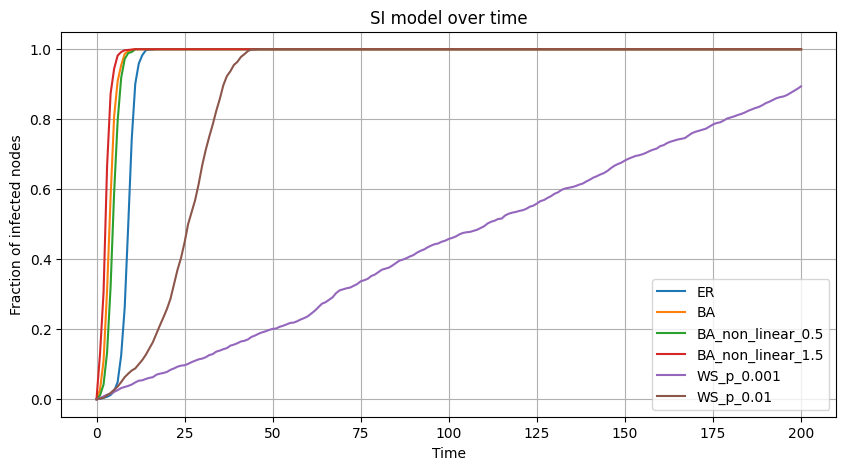

In [13]:
beta = 0.2

si_over_time = {
    name: si_time(G, beta, 200)
    for name, G in graphs.items()
}

plt.figure(figsize=(10, 5))

for name, (I, S, T) in si_over_time.items():
    plt.plot(T, I, label=name)

plt.xlabel("Time")
plt.ylabel("Fraction of infected nodes")
plt.title("SI model over time")
plt.legend()
plt.grid(True)
plt.show()

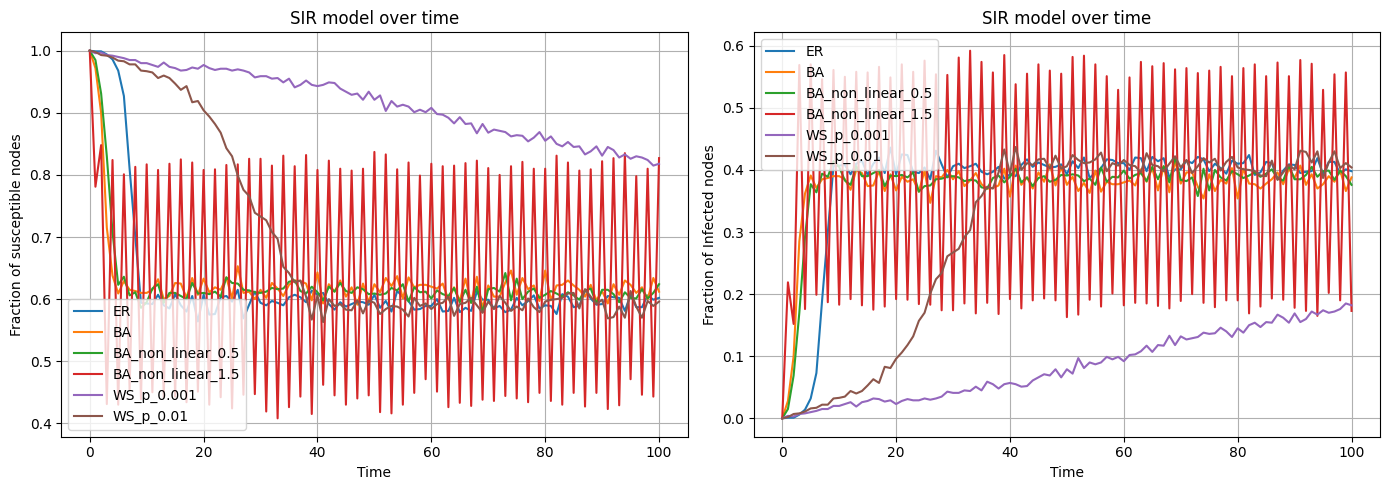

In [14]:
beta = 0.3
mu = 1
sis_over_time = {
    name: sis_time(G, beta,mu, 100)
    for name, G in graphs.items()
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, (I, S, T) in sis_over_time.items():
    ax1.plot(T, S, label=name)

ax1.set_xlabel("Time")
ax1.set_ylabel("Fraction of susceptible nodes")
ax1.set_title("SIR model over time")
ax1.legend()
ax1.grid(True)

for name, (I, S, T) in sis_over_time.items():
    ax2.plot(T, I, label=name)

ax2.set_xlabel("Time")
ax2.set_ylabel("Fraction of Infected nodes")
ax2.set_title("SIR model over time")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

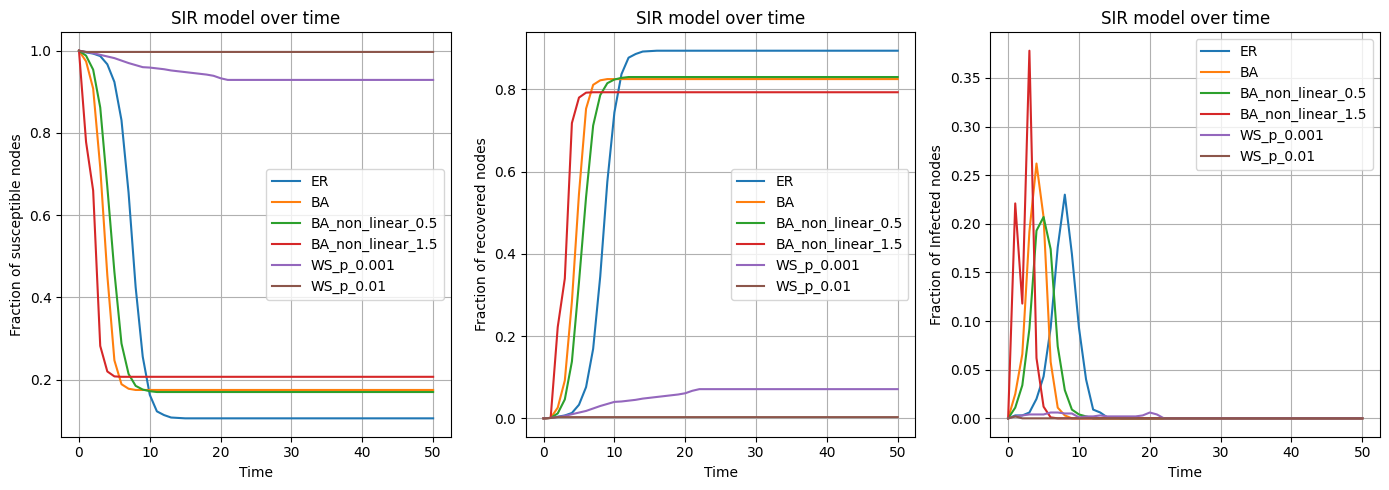

In [15]:
beta = 0.3
mu = 1
sir_over_time = {
    name: sir_time(G, beta, mu, 50)
    for name, G in graphs.items()
}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

for name, (I, S, R, T) in sir_over_time.items():
    ax1.plot(T, S, label=name)

ax1.set_xlabel("Time")
ax1.set_ylabel("Fraction of susceptible nodes")
ax1.set_title("SIR model over time")
ax1.legend()
ax1.grid(True)

for name, (I, S, R, T) in sir_over_time.items():
    ax2.plot(T, R, label=name)

ax2.set_xlabel("Time")
ax2.set_ylabel("Fraction of recovered nodes")
ax2.set_title("SIR model over time")
ax2.legend()
ax2.grid(True)

for name, (I, S, R, T) in sir_over_time.items():
    ax3.plot(T, I, label=name)

ax3.set_xlabel("Time")
ax3.set_ylabel("Fraction of Infected nodes")
ax3.set_title("SIR model over time")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

In [21]:
mu = 1

res_sim_alpha = {}

max_attempts = 100  # evita loop infinito

for name, G in graphs.items():
    res_sim_alpha[name] = {
        "mean_infected": [],
        "alpha": [],
        "attempts": []
    }

    for alpha in np.arange(0, 1, 0.05):
        beta = mu * alpha

        mean_value = 0
        attempts = 0

        while mean_value == 0 and attempts < max_attempts:
            I, _, _ = sis_time(G, beta, mu, 200)
            mean_value = np.mean(np.array(I))
            attempts += 1

        res_sim_alpha[name]["mean_infected"].append(mean_value)
        res_sim_alpha[name]["alpha"].append(alpha)
        res_sim_alpha[name]["attempts"].append(attempts)

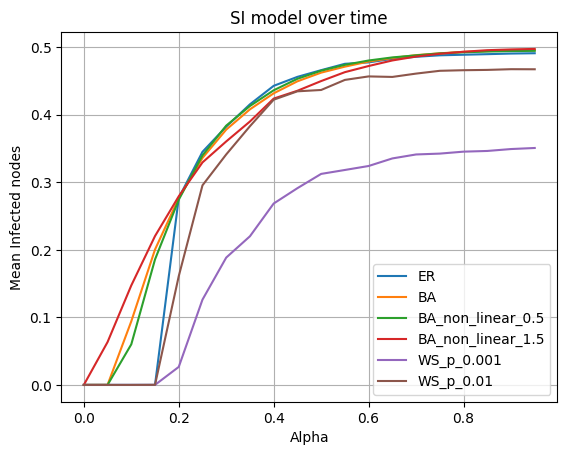

In [22]:

for name, res in res_sim_alpha.items():
    plt.plot(res["alpha"], res["mean_infected"], label=name)

plt.xlabel("Alpha")
plt.ylabel("Mean Infected nodes")
plt.title("SI model over time")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
print("Teórico")

for name, G in graphs.items():
    k1 = degree_moment(G, 1)
    k2 = degree_moment(G, 2)
    print(f"{name}: {(k1/k2):.3f}")

Teórico
ER: 0.111
BA: 0.060
BA_non_linear_0.5: 0.085
BA_non_linear_1.5: 0.006
WS_p_0.001: 0.125
WS_p_0.01: 0.125


## Imunização

A imunização pode ser alcançada de duas formas: artificialmente, quando o nó recebe uma "vacina", ou naturalmente, quando um nó é infectado e se recupera. Assim, o total de recuperados é a soma dos dois grupos:

$$R_{total} = R_{artificial} + R_{infecção}$$

onde $R_{artificial}$ corresponde aos nós imunizados (fração $p$) e $R_{infecção}$ aos nós que adoeceram e se curaram.

**Imunização aleatória.** O valor mínimo de recuperados acompanha o número de imunizados artificialmente ($R \approx p$). Esse piso corresponde às execuções em que o paciente zero não contamina nenhum vizinho e se recupera logo na sequência, de modo que a doença não se propaga e os únicos recuperados são os já imunizados.

**Imunização dos hubs.** Ao imunizar primeiro os nós mais conectados, o total de recuperados cai rapidamente: removendo os hubs, a rede atinge o limiar de imunidade de rebanho com uma fração pequena de imunizados, e a doença é erradicada antes de se tornar uma epidemia. A partir desse limiar (≈ 10% nesta rede), praticamente nenhum nó é infectado, e o total de recuperados passa a refletir apenas a imunização artificial ($R \approx p$). Essa "subida" não indica retorno da doença, e sim o componente epidêmico zerado — sobra apenas a contagem dos próprios vacinados.



In [41]:
def sir_time_with_immunisation(
          G: nx.Graph, 
          beta: float, 
          mu: float, 
          t_max: int, 
          immune_nodes: List[int], 
          t_immunisation: int = 0) -> tuple[List[float], List[float], List[float], List[int]]:
    
    population_size = G.number_of_nodes()
    population = np.zeros(population_size)

    for immune_node in immune_nodes:
        population[immune_node] = -1  


    patient_zero = np.random.choice(np.where(population==0)[0], size=1) ## randon select one patiente zero to be infected
    population[patient_zero] = 1 # infect first patient


    if t_immunisation == 0:
        p_immune = len(immune_nodes)/population_size
        I = [0]
        S = [1-p_immune]
        T = [0]
        R = [p_immune]
    else:
        I = [0]
        S = [1]
        T = [0]
        R = [0]

    for t in range(1, t_max+1):

        infecteds = np.where(population==1)[0]
        for i in infecteds: 
            neighbors = G.neighbors(i)
            for j in neighbors:
                if np.random.rand() < beta and population[j] == 0:
                    population[j] = 1
        for i in infecteds:
            if np.random.rand() < mu:
                    population[i] = -1 ## Curado e imune

        total_infecteds = np.count_nonzero(population == 1)
        total_susceptible = np.count_nonzero(population == 0)
        total_recovered = np.count_nonzero(population == -1)


        # immunisation after the spreading started
        if t_immunisation == t:
            for immune_node in immune_nodes:
                population[immune_node] = -1  
        
        I.append(total_infecteds/population_size)
        S.append(total_susceptible/population_size)
        R.append(total_recovered/population_size)
        T.append(t)


    return I, S, R, T

In [7]:
N = 1000
k = 8

# BA: grau médio esperado ~= 2m
m_ba = k // 2

G = nx.barabasi_albert_graph(
    n=N,
    m=m_ba,
    seed=seed
)


In [8]:
beta = 0.3
mu = 1

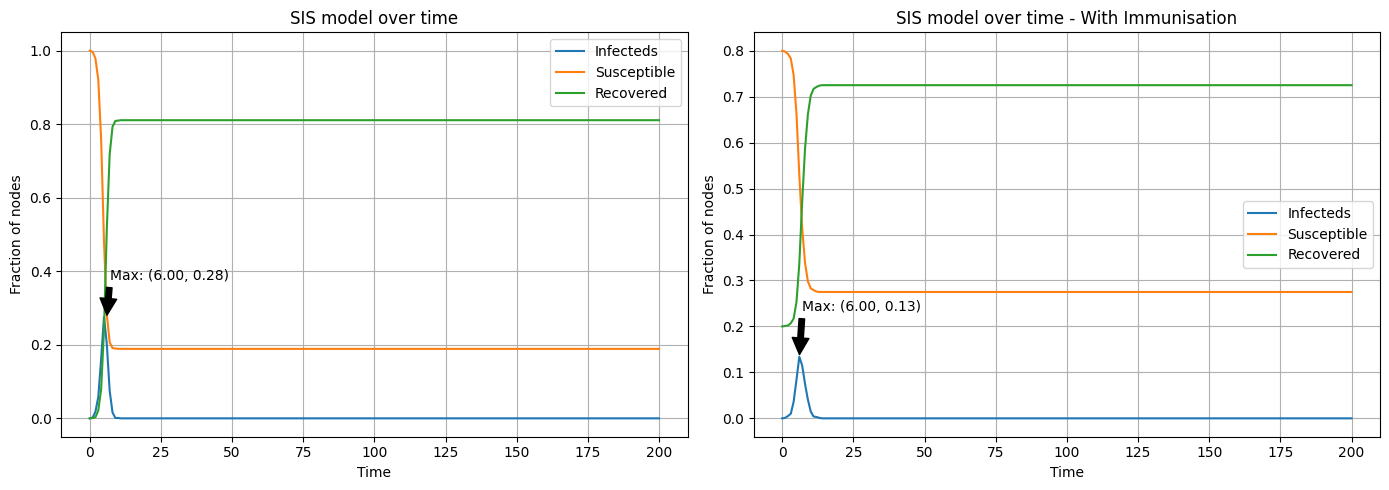

In [9]:
immune_nodes = np.random.choice(G, size=200, replace=False)

(I_imm, S_imm, R_imm, T_imm) = sir_time_with_immunisation(
    G=G,
    beta=beta,
    mu=mu,
    t_max = 200,
    immune_nodes = immune_nodes, 
    t_immunisation=0
)

(I, S, R, T) = sir_time_with_immunisation(
    G=G,
    beta=beta,
    mu=mu,
    t_max = 200,
    immune_nodes = [], 
    t_immunisation=0
)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(T, I, label="Infecteds")
ax1.plot(T, S, label="Susceptible")
ax1.plot(T, R, label="Recovered")
ax1.set_xlabel("Time")
ax1.set_ylabel("Fraction of nodes")
ax1.set_title("SIS model over time")
ax1.legend()
ax1.grid(True)
I_ymax = max(I)
T_xmax = T_imm[np.argmax(np.array(I_imm))]
ax1.annotate(f'Max: ({T_xmax:.2f}, {I_ymax:.2f})', 
            xy=(T_xmax, I_ymax), 
            xytext=(T_xmax + 1, I_ymax + 0.1),
            arrowprops=dict(facecolor='black', shrink=0.05))


ax2.plot(T, I_imm, label="Infecteds")
ax2.plot(T, S_imm, label="Susceptible")
ax2.plot(T, R_imm, label="Recovered")
ax2.set_xlabel("Time")
ax2.set_ylabel("Fraction of nodes")
ax2.set_title("SIS model over time - With Immunisation")
ax2.legend()
ax2.grid(True)

I_imm_ymax = max(I_imm)
T_imm_xmax = T_imm[np.argmax(np.array(I_imm))]
ax2.annotate(f'Max: ({T_imm_xmax:.2f}, {I_imm_ymax:.2f})', 
            xy=(T_imm_xmax, I_imm_ymax), 
            xytext=(T_imm_xmax + 1, I_imm_ymax + 0.1),
            arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

In [30]:
total_runs = 10
res_sim = [{"mean_recovered": [], "percentage_of_immune": []} for _ in range(total_runs)]

for i in range(0, total_runs):
    for p in np.arange(0, 0.6, 0.001):
        immune_nodes = np.random.choice(G, size=int(N*p), replace=False)

        (_, _, R_imm, T_imm) = sir_time_with_immunisation(
            G=G,
            beta=beta,
            mu=mu,
            t_max = 200,
            immune_nodes = immune_nodes, 
            t_immunisation=0
        )
        mean_value = np.mean(np.array(R_imm))

        res_sim[i]["mean_recovered"].append(mean_value)
        res_sim[i]["percentage_of_immune"].append(p)
    

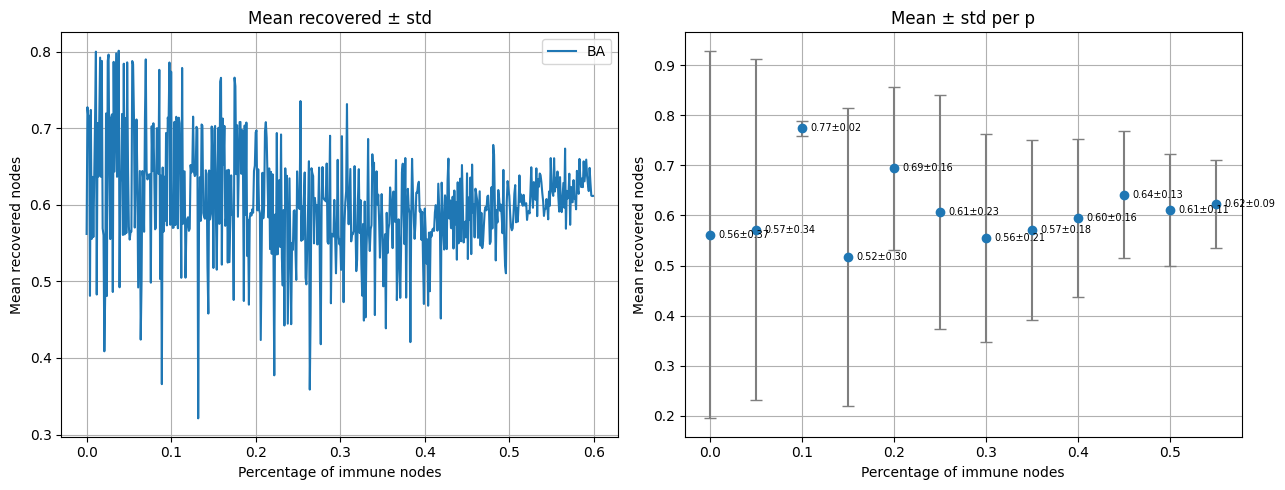

In [ ]:
p    = np.array(res_sim[0]["percentage_of_immune"])
runs = np.array([r["mean_recovered"] for r in res_sim])

mean = runs.mean(axis=0)
std  = runs.std(axis=0)

fig, (ax_line, ax_candle) = plt.subplots(1, 2, figsize=(13, 5))

# Esquerda: curva média + banda de ±1 std
ax_line.plot(p, mean, label="BA", color="tab:blue")
ax_line.set_xlabel("Percentage of immune nodes")
ax_line.set_ylabel("Mean recovered nodes")
ax_line.set_title("Mean recovered ± std")
ax_line.legend(); ax_line.grid(True)


step = max(1, len(p) // 12)
idx  = np.arange(0, len(p), step)

ax_candle.errorbar(p[idx], mean[idx], yerr=std[idx],
                   fmt="o", capsize=4, color="tab:blue", ecolor="tab:gray")

for xi, mi, si in zip(p[idx], mean[idx], std[idx]):
    ax_candle.annotate(f"{mi:.2f}±{si:.2f}", (xi, mi),
                       textcoords="offset points", xytext=(6, 0),
                       fontsize=7, va="center")

ax_candle.set_xlabel("Percentage of immune nodes")
ax_candle.set_ylabel("Mean recovered nodes")
ax_candle.set_title("Mean ± std per p")
ax_candle.grid(True)

plt.tight_layout()
plt.show()

In [37]:
total_runs = 10
res_sim = [{"mean_recovered": [], "percentage_of_immune": []} for _ in range(total_runs)]

# ranking por grau, do mais conectado pro menos — calculado UMA vez
nodes_by_degree = [n for n, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)]

for i in range(0, total_runs):
    for p in np.arange(0, 0.6, 0.001):
        k = int(N * p)
        immune_nodes = nodes_by_degree[:k]   # top-k hubs

        (_, _, R_imm, T_imm) = sir_time_with_immunisation(
            G=G,
            beta=beta,
            mu=mu,
            t_max=200,
            immune_nodes=immune_nodes,
            t_immunisation=0
        )
        mean_value = np.mean(np.array(R_imm))

        res_sim[i]["mean_recovered"].append(mean_value)
        res_sim[i]["percentage_of_immune"].append(p)

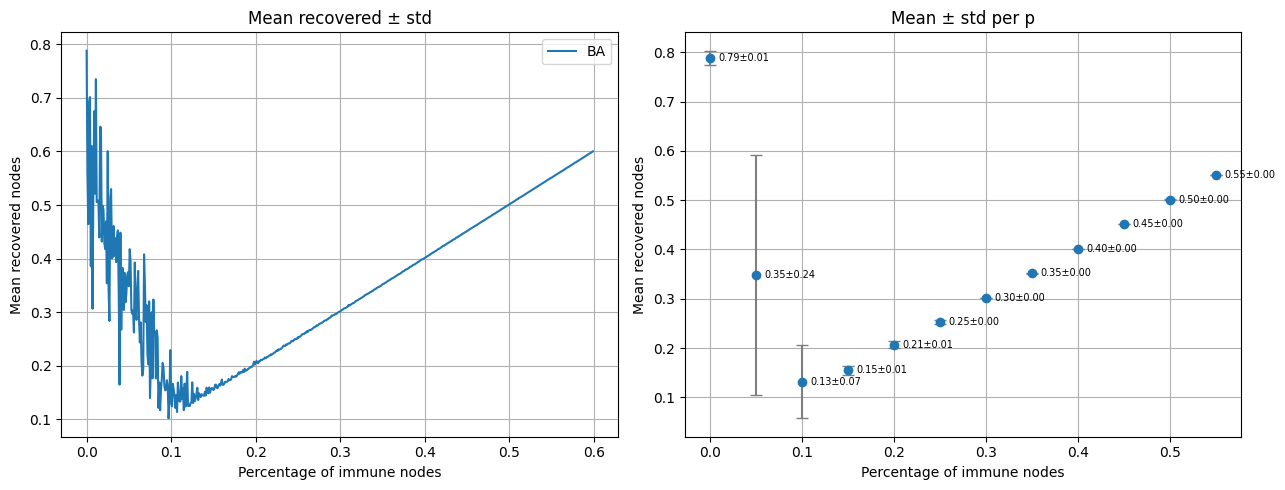

In [38]:
p    = np.array(res_sim[0]["percentage_of_immune"])
runs = np.array([r["mean_recovered"] for r in res_sim])

mean = runs.mean(axis=0)
std  = runs.std(axis=0)

fig, (ax_line, ax_candle) = plt.subplots(1, 2, figsize=(13, 5))

# Esquerda: curva média + banda de ±1 std
ax_line.plot(p, mean, label="BA", color="tab:blue")
ax_line.set_xlabel("Percentage of immune nodes")
ax_line.set_ylabel("Mean recovered nodes")
ax_line.set_title("Mean recovered ± std")
ax_line.legend(); ax_line.grid(True)


step = max(1, len(p) // 12)
idx  = np.arange(0, len(p), step)

ax_candle.errorbar(p[idx], mean[idx], yerr=std[idx],
                   fmt="o", capsize=4, color="tab:blue", ecolor="tab:gray")

for xi, mi, si in zip(p[idx], mean[idx], std[idx]):
    ax_candle.annotate(f"{mi:.2f}±{si:.2f}", (xi, mi),
                       textcoords="offset points", xytext=(6, 0),
                       fontsize=7, va="center")

ax_candle.set_xlabel("Percentage of immune nodes")
ax_candle.set_ylabel("Mean recovered nodes")
ax_candle.set_title("Mean ± std per p")
ax_candle.grid(True)

plt.tight_layout()
plt.show()